# Mirror-Prox pour les MFG avec pas proximal de Bregman ($\Gamma$)

Validation numerique de l'algorithme **Mirror-Prox** dont le pas proximal est
résolu **en forme fermée** via la divergence de Bregman $\Gamma$ de Moreno
(MD-CURL), c'est-à-dire une regularisation entropique sur la politique,
et non sur la mesure d'occupation $d$.

On teste sur une grille **quatre pieces** avec une recompense de **congestion** $r_h(s,a,\mu) = -c\,\mu_h(s)$. Ce terme rend l'operateur
$F(d) = -r(\cdot,\mu^d)$ **monotone** (condition de Lasry-Lions), garantissant
l'**unicite** du MFNE. La metrique de convergence est l'**exploitabilité**
(nulle si et seulement si on est au MFNE).

Conventions :
- $d(h,s,a) = \tfrac1H\,\mathbb{P}((s_h,a_h)=(s,a))$, donc $\sum_{h,s,a} d = 1$ ;
- $\mu_h(s) = H\sum_a d(h,s,a)$ (flot champ moyen), $\sum_s \mu_h(s)=1$ ; Ici avec le choix de $r$ et donc de $F$, on a que $r$ est proportionnel à $H$ et donc $L \propto H$ où $L$ est la constante de Lipschitz de $F$ (opérateur de la VI).
- $\bar d(h,s) = \sum_a d(h,s,a)$, avec $\bar d(1,s)=\xi(s)/H$.

Remarque : quand je mentionne Moreno, je parle notamment de l'article "Efficient Model-Based Concave Utility Reinforcement Learning through Greedy Mirror Descent" (2024).

In [1]:
import numpy as np
from scipy.special import logsumexp, softmax
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Environnement : grille quatre pieces

Espace d'etats = cellules d'une grille $n\times n$ avec deux murs (un horizontal,
un vertical) possédant des portes. Cinq actions : rester, haut, bas, gauche, droite.
Transition stationnaire $P[a,s,s']$, deterministe à un parametre de glissement
`slip` près (qui rend $P$ stochastique pour tester la propagation de la valeur).

In [2]:
ACTIONS = np.array([(0, 0), (-1, 0), (1, 0), (0, -1), (0, 1)])  # stay,up,down,left,right

def build_four_room(n=11, slip=0.05):
    mid = n // 2
    doors = {(mid, 2), (mid, n - 3), (2, mid), (n - 3, mid)}
    blocked = set()
    for c in range(n):
        if (mid, c) not in doors: blocked.add((mid, c))
    for r in range(n):
        if (r, mid) not in doors: blocked.add((r, mid))

    cells = [(r, c) for r in range(n) for c in range(n) if (r, c) not in blocked]
    cell_to_idx = {cell: i for i, cell in enumerate(cells)}
    coords = np.array(cells)
    nS, nA = len(cells), len(ACTIONS)

    def step(r, c, a):
        dr, dc = ACTIONS[a]
        return cell_to_idx.get((r + dr, c + dc), cell_to_idx[(r, c)]) # on récup

    P = np.zeros((nA, nS, nS))
    for s, (r, c) in enumerate(cells):
        outcomes = [step(r, c, a) for a in range(nA)]
        for a in range(nA):
            P[a, s, outcomes[a]] += (1.0 - slip) # 95% du temps l'environnement nous emmène là où on veut (case correspondant à notre action)
            for a2 in range(nA):
                P[a, s, outcomes[a2]] += slip / nA  # 5% du temps l'environnement nous emmène sur une des 5 positions au hasard => on peut ne pas faire "a" donc !
    P /= P.sum(axis=2, keepdims=True)
    return P, coords, cell_to_idx, (n, n), blocked

P, coords, c2i, grid_shape, blocked = build_four_room(n=11, slip=0.05)
nS, nA = P.shape[1], P.shape[0]
print(f"grille {grid_shape} | nS={nS} etats valides | nA={nA} actions")

grille (11, 11) | nS=104 etats valides | nA=5 actions


## 2. Recompense a champ moyen (congestion -> monotone)

$r_h(s,a,\mu) = g(s) - c\,\mu_h(s)$. Le terme $-c\,\mu_h(s)$ penalise la foule :
$\langle F(d)-F(d'),d-d'\rangle = \tfrac{c}{H}\sum_{h,s}(\mu^d_h(s)-\mu^{d'}_h(s))^2 \ge 0$,
donc $F$ est monotone et le MFNE est unique.

In [3]:
def make_reward(nS, nA, c_cong=1.0, g_state=None):
    if g_state is None:
        g_state = np.zeros(nS)
    def reward(mu_h):                       # mu_h:(nS,) -> r:(nS,nA)
        r_s = g_state - c_cong * mu_h    # changer le - en + pour casser la monotonie et voir ce qu'il se passe
        return np.repeat(r_s[:, None], nA, axis=1)
    return reward

reward = make_reward(nS, nA, c_cong=1.0)

## 3. Passe forward : derouler une politique pour obtenir $d\in\mathcal{K}_\xi$

$\bar d(1,\cdot)=\xi/H$, puis $d(h)=\bar d(h)\odot\pi(h)$ et
$\bar d(h{+}1,s')=\sum_{s,a} d(h,s,a)P[a,s,s']$. Garantit $d\in\mathcal{K}_\xi$ par construction.

In [4]:
def forward_unroll(pi, P, xi, H):
    nS, nA = pi.shape[1], pi.shape[2]
    d = np.zeros((H, nS, nA)); bar_d = np.zeros((H, nS))
    bar_d[0] = xi / H
    for h in range(H - 1):
        d[h] = bar_d[h][:, None] * pi[h]
        bar_d[h + 1] = np.einsum('sa,asx->x', d[h], P)
    d[H - 1] = bar_d[H - 1][:, None] * pi[H - 1]
    return d, bar_d

### 4. Prox-$\Gamma$ : pas proximal en forme fermee

Résout $\arg\min_{d\in\mathcal{K}_\xi}\langle-\gamma r(\cdot,\mu),d\rangle+\Gamma(d,d_{\mathrm{ref}})$.

**Passe backward** (soft value iteration), pour $h=H,\dots,1$ :
$$Q_h(s,a)=r_h(s,a,\mu_h)+\textstyle\sum_{s'}P(s'|s,a)V_{h+1}(s'),\quad
V_h(s)=\tfrac1\gamma\log\textstyle\sum_a\pi^{\mathrm{ref}}_h(a|s)e^{\gamma Q_h(s,a)},$$
$$\pi^{\mathrm{new}}_h(a|s)=\pi^{\mathrm{ref}}_h(a|s)\,e^{\gamma(Q_h(s,a)-V_h(s))}.$$
Le $\log\sum\exp$ est la valeur du $\max$ regularise (Eq. 10 de Moreno) ;
on l'evalue de facon stable avec `logsumexp`. Puis **passe forward** pour obtenir $d_{\mathrm{new}}$.

In [5]:
def prox_gamma(mu, d_ref, gamma, P, xi, reward, eps=1e-12):
    H, nS, nA = d_ref.shape
    bar_ref = d_ref.sum(axis=2)
    pi_ref = d_ref / np.maximum(bar_ref[:, :, None], eps)
    pi_ref[bar_ref < eps] = 1.0 / nA
    log_pi_ref = np.log(np.maximum(pi_ref, eps))

    pi_new = np.zeros((H, nS, nA))
    V_next = np.zeros(nS)                              # V_{H+1}=0
    for h in range(H - 1, -1, -1):
        Q = reward(mu[h]) + np.einsum('asx,x->sa', P, V_next)
        logits = log_pi_ref[h] + gamma * Q
        V_next = logsumexp(logits, axis=1) / gamma
        pi_new[h] = softmax(logits, axis=1)

    d_new, _ = forward_unroll(pi_new, P, xi, H)
    return d_new

## 5. Exploitabilite et boucle Mirror-Prox

**Exploitabilite** : $\mathrm{Exp}=\sum_s\xi(s)(V_{\mathrm{BR}}(s)-V_{\pi}(s))$, ou
$V_{\mathrm{BR}}$ est la valeur de la meilleure reponse et $V_\pi$ celle de
la politique courante, toutes deux contre le flot fixé $\mu^d$. Nulle ssi MFNE.

**Mirror-Prox** : extrapolation $d^{k+1/2}=\mathrm{prox}^\Gamma_{d^k}(\gamma F(d^k))$
puis correction $d^{k+1}=\mathrm{prox}^\Gamma_{d^k}(\gamma F(d^{k+1/2}))$ ; on moyenne
les demi-pas (Polyak-Ruppert).

A chaque pas $k$ de l'algo on traite tout l'horizon $H$.

In [6]:
def exploitability(d, P, xi, reward, eps=1e-12):
    H, nS, nA = d.shape
    mu = H * d.sum(axis=2)
    bar_d = d.sum(axis=2)
    pi = d / np.maximum(bar_d[:, :, None], eps); pi[bar_d < eps] = 1.0 / nA
    V_br = np.zeros(nS); V_pi = np.zeros(nS)
    for h in range(H - 1, -1, -1):
        r_h = reward(mu[h])
        V_br = (r_h + np.einsum('asx,x->sa', P, V_br)).max(axis=1)
        V_pi = (pi[h] * (r_h + np.einsum('asx,x->sa', P, V_pi))).sum(axis=1)
    return float(xi @ (V_br - V_pi))


def mirror_prox(P, xi, reward, H, K, gamma, verbose=True):
    nS, nA = P.shape[1], P.shape[0]
    pi0 = np.full((H, nS, nA), 1.0 / nA)
    d_k, _ = forward_unroll(pi0, P, xi, H)
    sum_half = np.zeros((H, nS, nA))
    exp_half, exp_avg = [], []
    for k in range(1, K + 1):
        mu_k = H * d_k.sum(axis=2)
        d_half = prox_gamma(mu_k, d_k, gamma, P, xi, reward)       # extrapolation
        mu_half = H * d_half.sum(axis=2)
        d_k = prox_gamma(mu_half, d_k, gamma, P, xi, reward)       # correction
        sum_half += d_half
        exp_half.append(exploitability(d_half, P, xi, reward))
        exp_avg.append(exploitability(sum_half / k, P, xi, reward))
        if verbose and (k <= 3 or k % max(1, K // 8) == 0):
            print(f"  iter {k:4d} | exp(d^k+1/2)={exp_half[-1]:.3e} | exp(avg)={exp_avg[-1]:.3e}")
    return sum_half / K, {'exp_half': np.array(exp_half), 'exp_avg': np.array(exp_avg)}

## 6. Experience

Distribution initiale $\xi$ = Dirac dans le coin haut-gauche. Le pas $\gamma$ doit
respecter $\gamma\lesssim 1/(\sqrt2 L)$ avec $L\propto H$ : pour $H=30$, $\gamma=1.0$
est stable. (Augmenter $H$ impose de reduire $\gamma$, sinon l'iteration oscille.)

In [7]:
xi = np.zeros(nS); xi[c2i[(0, 0)]] = 1.0
H, K, gamma = 30, 400, 1.0
d_bar, hist = mirror_prox(P, xi, reward, H, K, gamma, verbose=True)
print("exploitabilite finale (demi-pas) :", hist['exp_half'][-1])

  iter    1 | exp(d^k+1/2)=1.357e+00 | exp(avg)=1.357e+00
  iter    2 | exp(d^k+1/2)=1.171e+00 | exp(avg)=1.260e+00
  iter    3 | exp(d^k+1/2)=1.019e+00 | exp(avg)=1.173e+00
  iter   50 | exp(d^k+1/2)=1.144e-01 | exp(avg)=2.809e-01
  iter  100 | exp(d^k+1/2)=3.905e-02 | exp(avg)=1.665e-01
  iter  150 | exp(d^k+1/2)=2.176e-02 | exp(avg)=1.161e-01
  iter  200 | exp(d^k+1/2)=1.451e-02 | exp(avg)=8.864e-02
  iter  250 | exp(d^k+1/2)=1.109e-02 | exp(avg)=7.154e-02
  iter  300 | exp(d^k+1/2)=8.689e-03 | exp(avg)=5.992e-02
  iter  350 | exp(d^k+1/2)=6.968e-03 | exp(avg)=5.151e-02
  iter  400 | exp(d^k+1/2)=5.846e-03 | exp(avg)=4.514e-02
exploitabilite finale (demi-pas) : 0.0058460851684571935


## 7. Convergence de l'exploitabilite

Convergence en O(1/K) pour la moyenne ergodique des demi-pas ! On affiche aussi l'exploitabilité sur le demi-pas seul, permet d'observer une convergence de type last-iterate comme l'article "Last Iterate Convergence in Monotone Mean Field Games" d'Isobe et al.

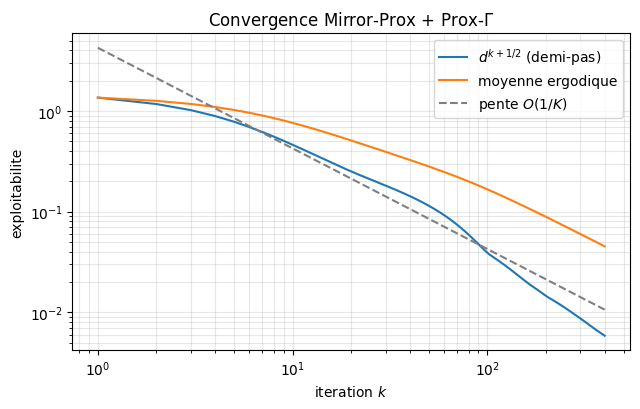

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ks = np.arange(1, K + 1)
ax.loglog(ks, hist['exp_half'], label=r'$d^{k+1/2}$ (demi-pas)')
ax.loglog(ks, hist['exp_avg'], label='moyenne ergodique')
ax.loglog(ks, hist['exp_half'][10] / (ks / 10), '--', color='gray', label=r'pente $O(1/K)$')
ax.set_xlabel('iteration $k$'); ax.set_ylabel('exploitabilite')
ax.legend(); ax.grid(True, which='both', alpha=.3)
ax.set_title('Convergence Mirror-Prox + Prox-$\\Gamma$')
fig.tight_layout(); plt.show()

## Convergence de la politique

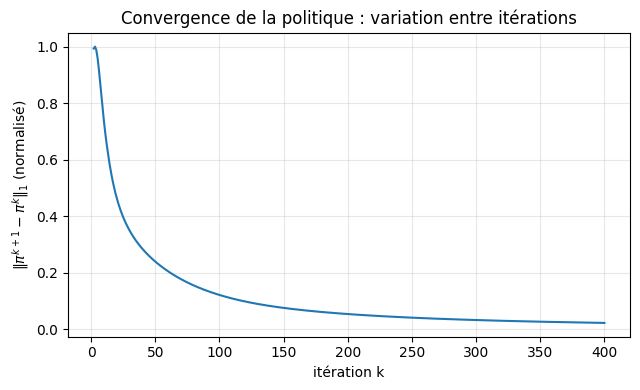

In [31]:
def mp_track_policy(P, xi, reward, H, K, gamma):
    """Mirror-Prox renvoyant la politique a chaque iteration."""
    pi0 = np.full((H, nS, nA), 1/nA)
    d_k, _ = forward_unroll(pi0, P, xi, H)
    sum_half = np.zeros((H, nS, nA)); pis = []
    for k in range(1, K+1):
        mu_k = H*d_k.sum(2)
        d_half = prox_gamma(mu_k, d_k, gamma, P, xi, reward)
        d_k = prox_gamma(H*d_half.sum(2), d_k, gamma, P, xi, reward)
        sum_half += d_half
        db = sum_half/k
        bar = db.sum(2); pi = db/np.maximum(bar[:, :, None], 1e-12); pi[bar < 1e-12] = 1/nA
        pis.append(pi)
    return np.array(pis)

K = 400
pis = mp_track_policy(P, xi, reward, H, K, gamma)

# variation consecutive : ||pi^{k+1} - pi^k||
diff = np.array([np.abs(pis[k] - pis[k-1]).sum() for k in range(1, len(pis))])

fig, ax = plt.subplots(figsize=(6.5, 4))
#ax.loglog(np.arange(2, K+1), np.maximum(diff, 1e-12))
#ax.set_xlabel('itération $k$'); ax.set_ylabel(r'$\|\pi^{k+1} - \pi^k\|_1$')

ax.plot(np.arange(2, K+1), diff / diff.max())   # lineaire, normalise a [0,1]
ax.set_xlabel('itération k'); ax.set_ylabel(r'$\|\pi^{k+1}-\pi^k\|_1$ (normalisé)')

ax.set_title('Convergence de la politique : variation entre itérations')
ax.grid(True, which='both', alpha=.3)
fig.tight_layout(); plt.show()

## 8. Flot champ moyen au MFNE

On visualise $\mu_h$ a plusieurs instants. Partant du Dirac en haut-gauche, la foule
diffuse a travers les portes vers les quatre pieces pour fuir la congestion :
c'est le comportement d'equilibre attendu.

Donc là, c'est le champ qu'on obtient en sortie de l'algo, Mirror-Prox nous a donné après l'itération $K$, un champ sur tout l'horizon qui converge vers un équilibre.

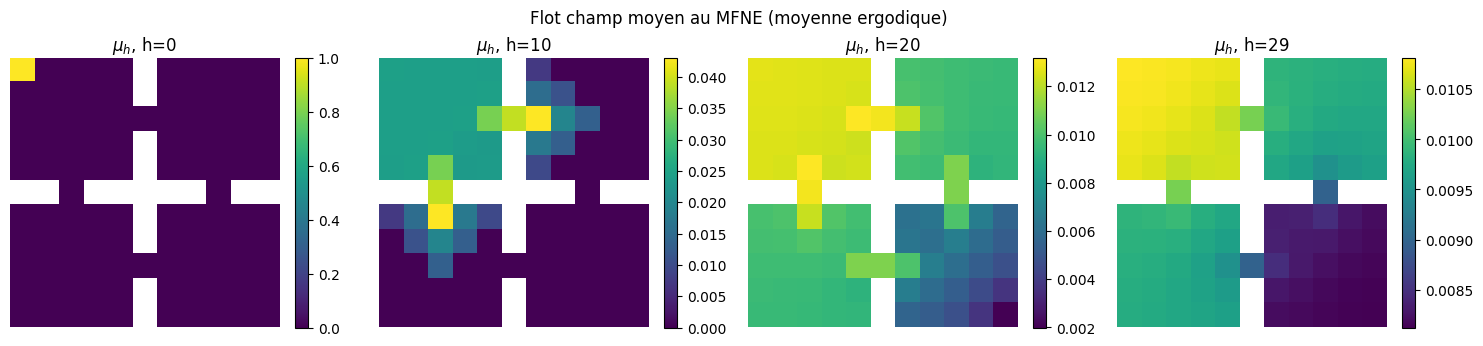

In [9]:
def to_grid(vec, coords, shape):
    g = np.full(shape, np.nan)
    for i, (r, c) in enumerate(coords): g[r, c] = vec[i]
    return g

mu_bar = H * d_bar.sum(axis=2)
hs = [0, H // 3, 2 * H // 3, H - 1]
fig, axes = plt.subplots(1, len(hs), figsize=(15, 3.4))
for ax, h in zip(axes, hs):
    im = ax.imshow(to_grid(mu_bar[h], coords, grid_shape), cmap='viridis')
    ax.set_title(f'$\\mu_h$, h={h}'); ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Flot champ moyen au MFNE (moyenne ergodique)')
fig.tight_layout(); plt.show()

## 9. Note sur la stabilite ($\gamma$ vs $H$)

Le pas admissible decroit quand l'horizon croit ($L\propto H$). Ci-dessous, un petit
balayage illustre le seuil de stabilite : au-dela d'un certain $\gamma$, l'exploitabilite
cesse d'etre monotone (oscillations), conformement a la condition $\gamma\lesssim 1/(\sqrt2 L)$.

In [26]:
for g in [0.5, 1.0, 1.5, 2.0, 3.0, 10.0]: # on fait varier gamma
    _, h = mirror_prox(P, xi, reward, H, 120, g, verbose=False)
    eh = h['exp_half']
    mono = np.all(np.diff(eh) <= 1e-9)
    print(f"gamma={g:4.1f} | exp_final={eh[-1]:.3e} | monotone_decroissant={mono}")

gamma= 0.5 | exp_final=9.174e-02 | monotone_decroissant=True
gamma= 1.0 | exp_final=3.032e-02 | monotone_decroissant=True
gamma= 1.5 | exp_final=4.636e-02 | monotone_decroissant=True
gamma= 2.0 | exp_final=3.340e-01 | monotone_decroissant=False
gamma= 3.0 | exp_final=3.932e-01 | monotone_decroissant=False
gamma=10.0 | exp_final=2.115e+00 | monotone_decroissant=False


## Regardons plus en détail ce qu'il se passe dans l'algo

In [27]:
def mirror_prox_snap(P, xi, reward, H, K, gamma, snap_iters):
    """Comme mirror_prox, mais memorise la moyenne ergodique d_bar a certaines iterations k."""
    nS, nA = P.shape[1], P.shape[0]
    pi0 = np.full((H, nS, nA), 1.0 / nA)
    d_k, _ = forward_unroll(pi0, P, xi, H)
    sum_half = np.zeros((H, nS, nA))
    exp_half, snaps = [], {}
    for k in range(1, K + 1):
        mu_k = H * d_k.sum(axis=2)
        d_half = prox_gamma(mu_k, d_k, gamma, P, xi, reward)        # extrapolation
        mu_half = H * d_half.sum(axis=2)
        d_k = prox_gamma(mu_half, d_k, gamma, P, xi, reward)        # correction
        sum_half += d_half
        exp_half.append(exploitability(d_half, P, xi, reward))
        if k in snap_iters:
            snaps[k] = (sum_half / k).copy()                       # d_bar a l'iteration k
    return sum_half / K, np.array(exp_half), snaps

snap_iters = [1, 5, 25, 100, K]
d_bar, exp_half, snaps = mirror_prox_snap(P, xi, reward, H, K, gamma, snap_iters)
print("captures aux iterations :", list(snaps.keys()))

captures aux iterations : [1, 5, 25, 100, 400]


## 10. Comment l'algo converge : le flot au fil des itérations

À horizon fixé `h`, on regarde le flot $\mu_h$ produit par la moyenne ergodique
$\bar d^k$ pour des itérations $k$ croissantes. On voit l'algorithme approcher
progressivement le flot d'équilibre (analogue des Figures 6–9 de Moreno).

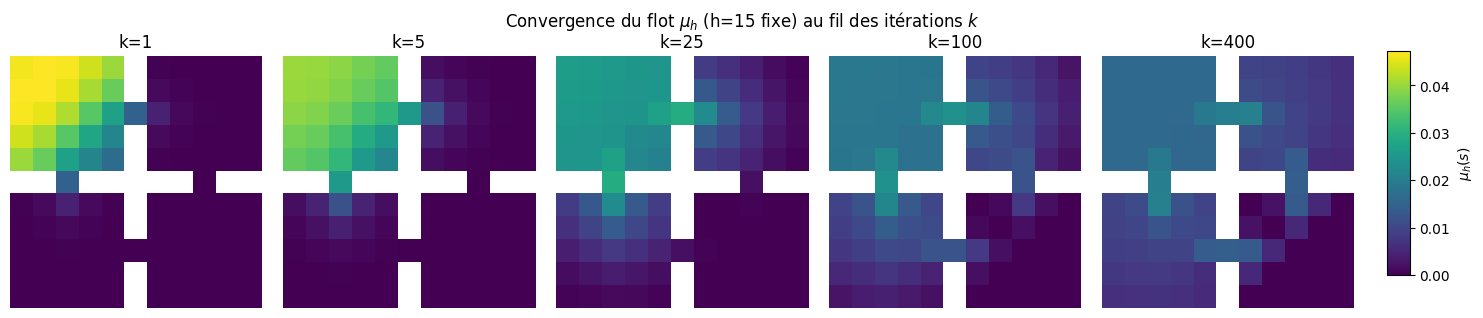

In [28]:
h_fix = H // 2
fig, axes = plt.subplots(1, len(snap_iters), figsize=(15, 3.2))
vmax = max((H * snaps[k].sum(2))[h_fix].max() for k in snap_iters)

im = None
for ax, k in zip(axes, snap_iters):
    mu_k = H * snaps[k].sum(axis=2)
    im = ax.imshow(to_grid(mu_k[h_fix], coords, grid_shape),
                   cmap='viridis', vmin=0, vmax=vmax)
    ax.set_title(f'k={k}'); ax.axis('off')

# une seule colorbar partagee a droite (echelle commune a toutes les sous-figures)
fig.suptitle(f'Convergence du flot $\\mu_h$ (h={h_fix} fixe) au fil des itérations $k$')
fig.tight_layout(rect=[0, 0, 0.92, 1])          # laisse 8% a droite pour la colorbar
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])  # [gauche, bas, largeur, hauteur]
fig.colorbar(im, cax=cbar_ax, label=r'$\mu_h(s)$')
plt.show()

## 11. Le couple d'équilibre $(\pi^\star, \mu^\star)$ : politique en flèches

On extrait $\pi^\star_h(a|s)=\bar d^K(h,s,a)/\sum_{a'}\bar d^K(h,s,a')$ et on superpose,
sur le flot $\mu^\star_h$ (en bleu), l'**action la plus probable** par état (flèche ;
point rouge = rester). On voit les agents fuir le coin surpeuplé vers les portes et
les pièces voisines : c'est la meilleure réponse à la congestion.

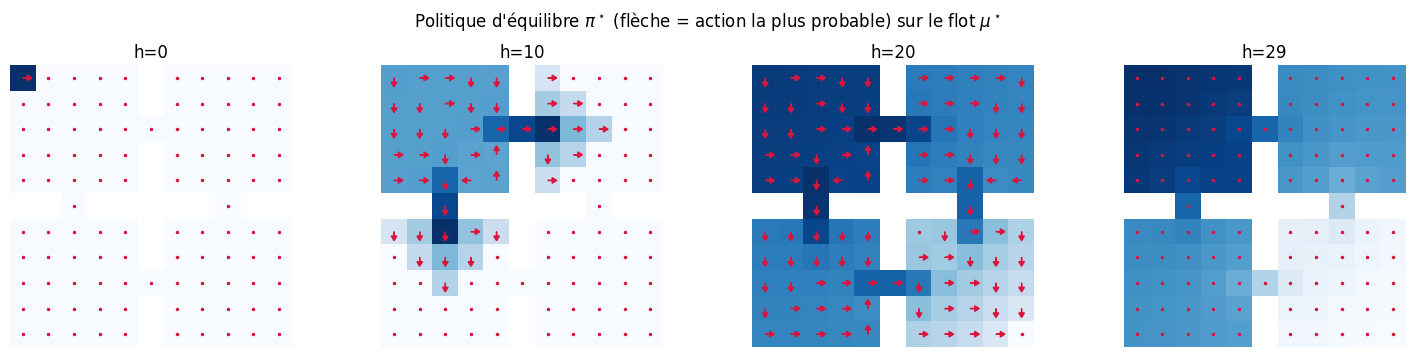

In [29]:
ARROW = {1: (0, -0.35), 2: (0, 0.35), 3: (-0.35, 0), 4: (0.35, 0)}  # haut,bas,gauche,droite

def plot_policy(ax, pi_h, mu_h, coords, shape, title):
    ax.imshow(to_grid(mu_h, coords, shape), cmap='Blues')
    for i, (r, c) in enumerate(coords):
        a = int(pi_h[i].argmax())
        if a == 0:
            ax.plot(c, r, '.', color='crimson', ms=3)                # rester
        else:
            dx, dy = ARROW[a]
            ax.arrow(c, r, dx, dy, head_width=0.22, head_length=0.18,
                     fc='crimson', ec='crimson', length_includes_head=True)
    ax.set_title(title); ax.axis('off')

bar_bar = d_bar.sum(axis=2)
pi_star = d_bar / np.maximum(bar_bar[:, :, None], 1e-12)
pi_star[bar_bar < 1e-12] = 1.0 / nA
mu_star = H * d_bar.sum(axis=2)

hs = [0, H // 3, 2 * H // 3, H - 1]
fig, axes = plt.subplots(1, len(hs), figsize=(15, 3.6))
for ax, h in zip(axes, hs):
    plot_policy(ax, pi_star[h], mu_star[h], coords, grid_shape, f'h={h}')
fig.suptitle("Politique d'équilibre $\\pi^\\star$ (flèche = action la plus probable) sur le flot $\\mu^\\star$")
fig.tight_layout(); plt.show()

Si je mets les couleurs sur la même échelle au fil des $h$ ça devient illisible car le dirac de $h=0$ est tellement fort par rapport aux temps d'après.

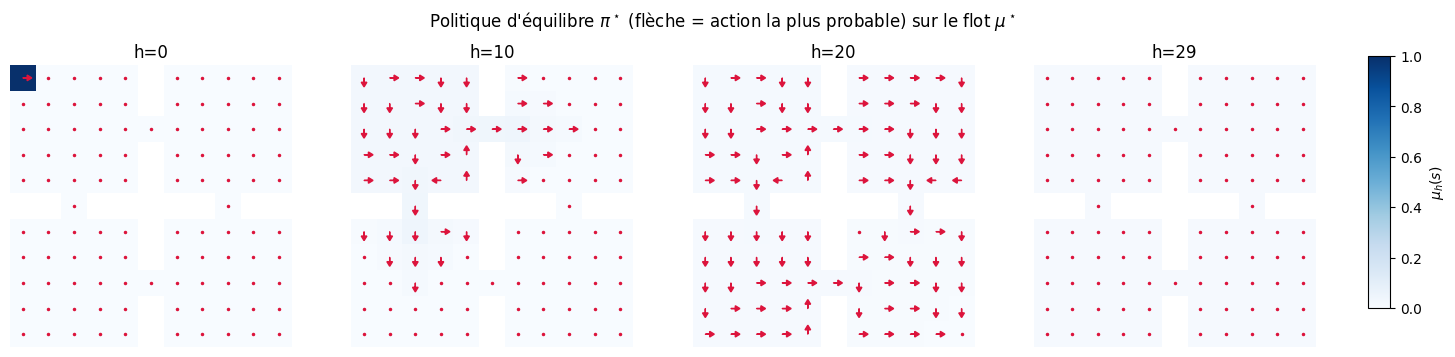

In [30]:
ARROW = {1: (0, -0.35), 2: (0, 0.35), 3: (-0.35, 0), 4: (0.35, 0)}

def plot_policy(ax, pi_h, mu_h, coords, shape, title, vmin, vmax):
    im = ax.imshow(to_grid(mu_h, coords, shape), cmap='Blues', vmin=vmin, vmax=vmax)
    for i, (r, c) in enumerate(coords):
        a = int(pi_h[i].argmax())
        if a == 0:
            ax.plot(c, r, '.', color='crimson', ms=3)
        else:
            dx, dy = ARROW[a]
            ax.arrow(c, r, dx, dy, head_width=0.22, head_length=0.18,
                     fc='crimson', ec='crimson', length_includes_head=True)
    ax.set_title(title); ax.axis('off')
    return im

bar_bar = d_bar.sum(axis=2)
pi_star = d_bar / np.maximum(bar_bar[:, :, None], 1e-12)
pi_star[bar_bar < 1e-12] = 1.0 / nA
mu_star = H * d_bar.sum(axis=2)

hs = [0, H // 3, 2 * H // 3, H - 1]
vmin = 0.0
vmax = max(mu_star[h].max() for h in hs)          # echelle commune a tous les h

fig, axes = plt.subplots(1, len(hs), figsize=(15, 3.6))
im = None
for ax, h in zip(axes, hs):
    im = plot_policy(ax, pi_star[h], mu_star[h], coords, grid_shape, f'h={h}', vmin, vmax)

fig.suptitle("Politique d'équilibre $\\pi^\\star$ (flèche = action la plus probable) sur le flot $\\mu^\\star$")
fig.tight_layout(rect=[0, 0, 0.92, 1])
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label=r'$\mu_h(s)$')
plt.show()

## 12. Diagnostics du couple $(\pi^\star, \mu^\star)$

Les deux conditions du MFNE :
- **Consistance** ($\mu^\star$ est bien la population engendrée par $\pi^\star$) : satisfaite
  exactement (à la précision machine), car $\bar d^K\in\mathcal{K}_\xi$ par convexité et la
  bijection de Moreno garantit que ré-enrouler $\pi^\star$ reproduit $\bar d^K$.
- **Optimalité** ($\pi^\star$ est meilleure réponse à $\mu^\star$) : mesurée par l'exploitabilité
  qui tend vers 0.

On affiche aussi l'entropie de $\pi^\star$ : à l'équilibre crowd-averse, la politique est
volontairement **mixte** (les agents se répartissent), donc l'entropie reste élevée : ce
n'est pas une politique déterministe.

In [14]:
# 1) Consistance pi* <-> mu* : re-enrouler pi* doit reproduire d_bar
d_re, _ = forward_unroll(pi_star, P, xi, H)
consistance = np.abs(d_re - d_bar).max()

# 2) d_bar respecte-t-il les contraintes de flux de K_xi ?
flux_err = max(np.abs(d_bar[h].sum(1) - np.einsum('sa,asx->x', d_bar[h-1], P)).max()
               for h in range(1, H))

# 3) Optimalite : exploitabilite de l'equilibre
exp_final = exploitability(d_bar, P, xi, reward)

# 4) Caractere mixte de la politique : entropie moyenne (max = log|A|)
ent = -(pi_star * np.log(np.maximum(pi_star, 1e-12))).sum(axis=2)

print(f"Consistance  |unroll(pi*) - d_bar|_inf : {consistance:.2e}  (=> mu* engendre par pi*)")
print(f"Flux K_xi    erreur max                : {flux_err:.2e}  (=> d_bar in K_xi)")
print(f"Optimalite   exploitabilite(d_bar)     : {exp_final:.3e} (=> ~0 au MFNE)")
print(f"Politique    entropie moyenne de pi*   : {ent.mean():.3f} / {np.log(nA):.3f} (mixte)")

Consistance  |unroll(pi*) - d_bar|_inf : 5.20e-18  (=> mu* engendre par pi*)
Flux K_xi    erreur max                : 8.67e-18  (=> d_bar in K_xi)
Optimalite   exploitabilite(d_bar)     : 4.514e-02 (=> ~0 au MFNE)
Politique    entropie moyenne de pi*   : 1.534 / 1.609 (mixte)


## 13. Validation par simulation : donner $\pi^\star$ à une vraie foule

On lâche $M$ agents qui jouent réellement
$\pi^\star$ en **échantillonnant** leurs actions et leurs transitions via $P$
(cette fois on tire vraiment au hasard, contrairement à l'algorithme qui propage
les distributions de façon exacte). On vérifie que l'histogramme empirique de la
foule reproduit le flot $\mu^\star$ calculé analytiquement, et que l'écart
décroît en $1/\sqrt{M}$ (loi des grands nombres / TCL).

In [15]:
def sample_cat(probs, rng):
    """Tirage catégoriel vectorisé : probs (M,K) -> indices (M,)."""
    c = np.cumsum(probs, axis=1)
    u = rng.random((probs.shape[0], 1))
    return (c > u).argmax(axis=1)

def simulate(pi, P, xi, H, M, seed=0):
    """M agents jouent pi en échantillonnant réellement états et actions.
       Retourne mu_emp (H,nS) = distribution empirique des états par pas h."""
    rng = np.random.default_rng(seed)
    nS = P.shape[1]
    states = sample_cat(np.tile(xi, (M, 1)), rng)        # s_0 ~ xi
    mu_emp = np.zeros((H, nS))
    for h in range(H):
        np.add.at(mu_emp[h], states, 1.0)                # histogramme des positions
        a = sample_cat(pi[h][states], rng)               # a_h ~ pi_h(.|s)
        if h < H - 1:
            states = sample_cat(P[a, states], rng)       # s_{h+1} ~ P[a,s,.]
    return mu_emp / M

# extraction du couple d'equilibre (si pas deja fait)
bar_bar = d_bar.sum(axis=2)
pi_star = d_bar / np.maximum(bar_bar[:, :, None], 1e-12); pi_star[bar_bar < 1e-12] = 1.0 / nA
mu_star = H * d_bar.sum(axis=2)

M = 20000
mu_emp = simulate(pi_star, P, xi, H, M, seed=0)
err = np.abs(mu_emp - mu_star).sum(axis=1).mean()
print(f"M={M} agents | erreur L1 moyenne |mu_emp - mu*| = {err:.4f}")

M=20000 agents | erreur L1 moyenne |mu_emp - mu*| = 0.0394


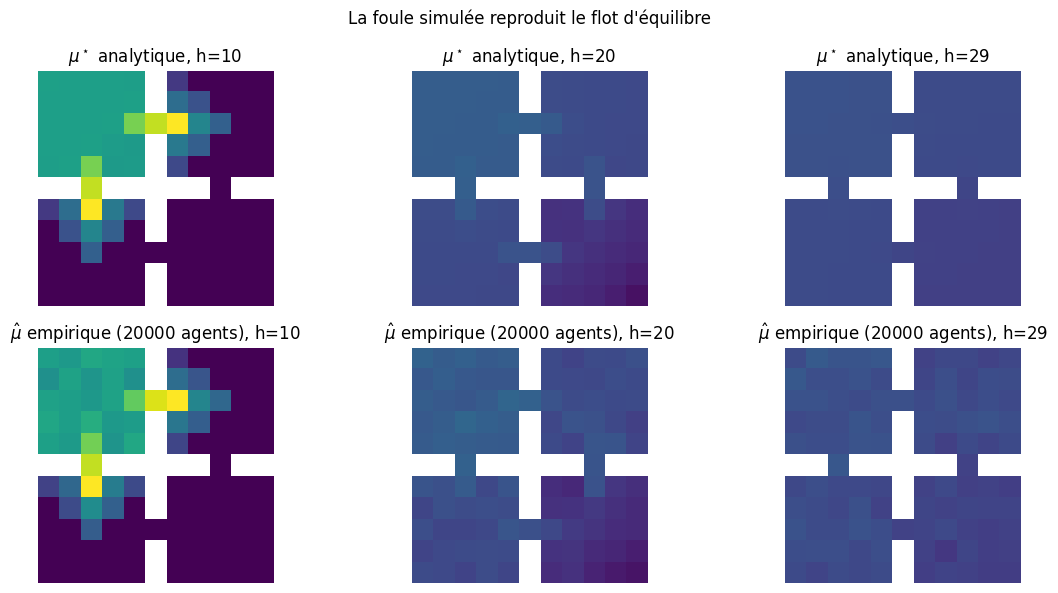

In [16]:
hs = [H // 3, 2 * H // 3, H - 1]
fig, axes = plt.subplots(2, len(hs), figsize=(12, 6))
vmax = mu_star[hs].max()
for j, h in enumerate(hs):
    axes[0, j].imshow(to_grid(mu_star[h], coords, grid_shape), cmap='viridis', vmin=0, vmax=vmax)
    axes[0, j].set_title(f'$\\mu^\\star$ analytique, h={h}'); axes[0, j].axis('off')
    axes[1, j].imshow(to_grid(mu_emp[h], coords, grid_shape), cmap='viridis', vmin=0, vmax=vmax)
    axes[1, j].set_title(f'$\\hat\\mu$ empirique ({M} agents), h={h}'); axes[1, j].axis('off')
fig.suptitle('La foule simulée reproduit le flot d\'équilibre')
fig.tight_layout(); plt.show()

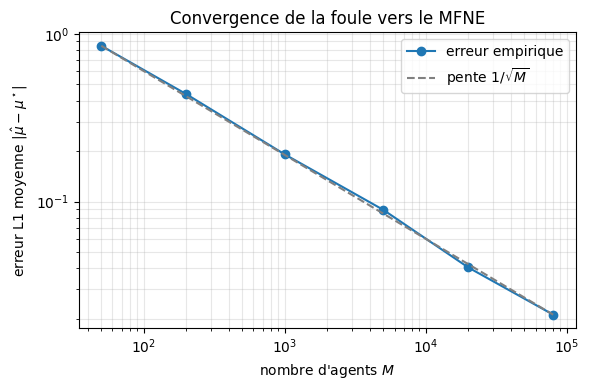

In [17]:
Ms = [50, 200, 1000, 5000, 20000, 80000]
errs = [np.abs(simulate(pi_star, P, xi, H, m, seed=1) - mu_star).sum(1).mean() for m in Ms]

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(Ms, errs, 'o-', label='erreur empirique')
ax.loglog(Ms, errs[0] * np.sqrt(Ms[0] / np.array(Ms)), '--', color='gray', label=r'pente $1/\sqrt{M}$')
ax.set_xlabel('nombre d\'agents $M$'); ax.set_ylabel('erreur L1 moyenne $|\\hat\\mu - \\mu^\\star|$')
ax.legend(); ax.grid(True, which='both', alpha=.3)
ax.set_title('Convergence de la foule vers le MFNE')
fig.tight_layout(); plt.show()

## 15. Variante : transitions dépendant du champ moyen $P_h(\cdot|s,a,\mu_h)$

On lève l'hypothèse A.1 : la dynamique elle-même dépend de la foule (congestion
**physique**). Modèle : la probabilité d'effectuer le déplacement voulu vers une
case cible $s'$ est atténuée par $(1-\kappa\,\mu_h(s'))$ : plus la cible est dense,
plus on a de chances de rester sur place (la foule freine).

**Stratégie de résolution (champ moyen figé).** À chaque itération $k$, on évalue
le noyau au flot courant $P^k := P[\mu^k]$ et on fige ce noyau pendant le calcul de
la meilleure réponse. À $\mu^k$ fixé, $P^k$ est constant, donc $\mathcal{K}_\xi^k$
redevient un polytope convexe et la forme fermée du prox s'applique **inchangée** :
c'est un MDP avec un autre noyau. Le couplage $\mu\to P$ agit *entre* les itérations.

In [18]:
ACTIONS = np.array([(0,0),(-1,0),(1,0),(0,-1),(0,1)])

def build_targets(n=11):
    """Comme build_four_room mais retourne target[a,s] = case visée par a depuis s."""
    mid = n//2; doors = {(mid,2),(mid,n-3),(2,mid),(n-3,mid)}; blocked = set()
    for c in range(n):
        if (mid,c) not in doors: blocked.add((mid,c))
    for r in range(n):
        if (r,mid) not in doors: blocked.add((r,mid))
    cells = [(r,c) for r in range(n) for c in range(n) if (r,c) not in blocked]
    c2i = {cell:i for i,cell in enumerate(cells)}; coords = np.array(cells)
    nS, nA = len(cells), len(ACTIONS)
    target = np.zeros((nA,nS), dtype=int)
    for s,(r,c) in enumerate(cells):
        for a in range(nA):
            dr,dc = ACTIONS[a]; target[a,s] = c2i.get((r+dr,c+dc), s)
    return target, coords, c2i, (n,n), blocked, nS, nA

def make_P_of_mu(target, nS, nA, base_slip=0.05, kappa=0.9):
    """Renvoie mu_h (nS,) -> P (nA,nS,nS). Mouvement freiné par (1-kappa*mu(cible))."""
    def P_of_mu(mu_h):
        P = np.zeros((nA,nS,nS)); sidx = np.arange(nS)
        for a in range(nA):
            tgt = target[a]
            mv = np.clip((1-base_slip)*(1-kappa*mu_h[tgt]), 0, 1)   # proba de bouger
            P[a,sidx,tgt] += mv; P[a,sidx,sidx] += 1-mv            # bouge sinon reste
            for a2 in range(nA):                                   # bruit de glissement
                P[a,sidx,target[a2]] += base_slip/nA
        P /= P.sum(2, keepdims=True)
        return P
    return P_of_mu

target, coords, c2i, grid_shape, blocked, nS, nA = build_targets(11)
P_of_mu = make_P_of_mu(target, nS, nA, kappa=0.9)
reward = make_reward(nS, nA, c_cong=1.0)
xi = np.zeros(nS); xi[c2i[(0,0)]] = 1.0

In [19]:
def P_flow(P_of_mu, mu):
    """Noyau figé par pas de temps : P_flow[h] = P évalué au flot mu[h]."""
    return [P_of_mu(mu[h]) for h in range(len(mu))]

def prox_gamma_flow(mu, d_ref, gamma, Pf, xi, reward, eps=1e-12):
    """Prox-Gamma quand le noyau figé Pf[h] dépend de h."""
    H, nS, nA = d_ref.shape
    bar = d_ref.sum(2); pi_ref = d_ref/np.maximum(bar[:,:,None], eps); pi_ref[bar<eps] = 1/nA
    logpi = np.log(np.maximum(pi_ref, eps)); pi_new = np.zeros((H,nS,nA)); V = np.zeros(nS)
    for h in range(H-1, -1, -1):                                   # backward
        Q = reward(mu[h]) + np.einsum('asx,x->sa', Pf[h], V)
        lo = logpi[h] + gamma*Q; V = logsumexp(lo, 1)/gamma; pi_new[h] = softmax(lo, 1)
    d = np.zeros((H,nS,nA)); bard = np.zeros((H,nS)); bard[0] = xi/H  # forward avec Pf figé
    for h in range(H-1):
        d[h] = bard[h][:,None]*pi_new[h]; bard[h+1] = np.einsum('sa,asx->x', d[h], Pf[h])
    d[H-1] = bard[H-1][:,None]*pi_new[H-1]
    return d

def unroll_Pmu(pi, P_of_mu, xi, H):
    """Déroulé sous le VRAI noyau dépendant de mu (mu[h] connu avant de pousser vers h+1)."""
    nS, nA = pi.shape[1], pi.shape[2]
    d = np.zeros((H,nS,nA)); bard = np.zeros((H,nS)); bard[0] = xi/H; mu = np.zeros((H,nS))
    for h in range(H):
        mu[h] = H*bard[h]; d[h] = bard[h][:,None]*pi[h]
        if h < H-1: bard[h+1] = np.einsum('sa,asx->x', d[h], P_of_mu(mu[h]))
    return d, mu

def exploit_Pmu(d, P_of_mu, xi, reward, eps=1e-12):
    H, nS, nA = d.shape; mu = H*d.sum(2)
    bar = d.sum(2); pi = d/np.maximum(bar[:,:,None], eps); pi[bar<eps] = 1/nA
    Pf = P_flow(P_of_mu, mu); Vbr = np.zeros(nS); Vpi = np.zeros(nS)
    for h in range(H-1, -1, -1):
        r = reward(mu[h])
        Vbr = (r + np.einsum('asx,x->sa', Pf[h], Vbr)).max(1)
        Vpi = (pi[h]*(r + np.einsum('asx,x->sa', Pf[h], Vpi))).sum(1)
    return float(xi @ (Vbr - Vpi))

  k=   1 | exp(d^k+1/2)=1.393e+00 | exp(moyenne)=1.393e+00
  k=   2 | exp(d^k+1/2)=1.183e+00 | exp(moyenne)=1.283e+00
  k=  66 | exp(d^k+1/2)=8.424e-02 | exp(moyenne)=2.302e-01
  k= 132 | exp(d^k+1/2)=2.703e-02 | exp(moyenne)=1.307e-01
  k= 198 | exp(d^k+1/2)=1.520e-02 | exp(moyenne)=8.921e-02
  k= 264 | exp(d^k+1/2)=1.006e-02 | exp(moyenne)=6.727e-02
  k= 330 | exp(d^k+1/2)=7.208e-03 | exp(moyenne)=5.387e-02
  k= 396 | exp(d^k+1/2)=5.568e-03 | exp(moyenne)=4.487e-02

exploitabilité finale (demi-pas)        : 5.492e-03
exploitabilité finale (moyenne ergodique): 4.442e-02
résidu de consistance                    : 3.674e-06 (-> 0 avec la convergence)


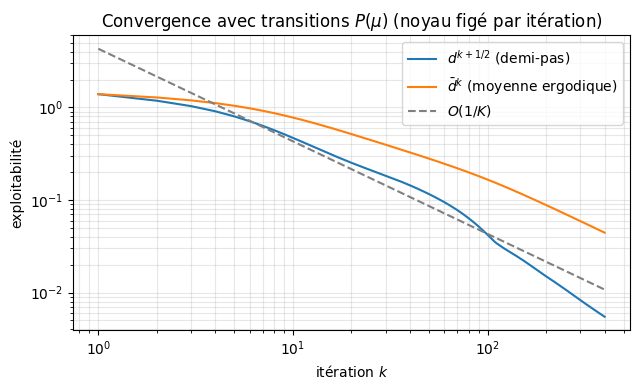

In [22]:
def mirror_prox_Pmu(P_of_mu, xi, reward, H, K, gamma, verbose=True):
    pi0 = np.full((H,nS,nA), 1/nA); d_k, _ = unroll_Pmu(pi0, P_of_mu, xi, H)
    sum_half = np.zeros((H,nS,nA))
    exps = []          # exploitabilité du demi-pas d^{k+1/2}
    exps_avg = []      # exploitabilité de la moyenne ergodique (1/k) sum d^{j+1/2}
    for k in range(1, K+1):
        mu_k = H*d_k.sum(2)
        d_half = prox_gamma_flow(mu_k, d_k, gamma, P_flow(P_of_mu, mu_k), xi, reward)   # extrap.
        mu_h = H*d_half.sum(2)
        d_k = prox_gamma_flow(mu_h, d_k, gamma, P_flow(P_of_mu, mu_h), xi, reward)      # corr.
        sum_half += d_half
        d_bar_k = sum_half / k                                  # moyenne ergodique courante
        exps.append(exploit_Pmu(d_half, P_of_mu, xi, reward))
        exps_avg.append(exploit_Pmu(d_bar_k, P_of_mu, xi, reward))
        if verbose and (k <= 2 or k % (K//6) == 0):
            print(f"  k={k:4d} | exp(d^k+1/2)={exps[-1]:.3e} | exp(moyenne)={exps_avg[-1]:.3e}")
    return sum_half/K, np.array(exps), np.array(exps_avg)

H, K, gamma = 30, 400, 1.0
d_bar, exps, exps_avg = mirror_prox_Pmu(P_of_mu, xi, reward, H, K, gamma)

# consistance (point fixe) : re-enrouler pi* sous P(mu*) reproduit-il d_bar ?
bar = d_bar.sum(2); pi_star = d_bar/np.maximum(bar[:,:,None], 1e-12); pi_star[bar<1e-12] = 1/nA
d_re, _ = unroll_Pmu(pi_star, P_of_mu, xi, H)
print(f"\nexploitabilité finale (demi-pas)        : {exps[-1]:.3e}")
print(f"exploitabilité finale (moyenne ergodique): {exps_avg[-1]:.3e}")
print(f"résidu de consistance                    : {np.abs(d_re - d_bar).max():.3e} (-> 0 avec la convergence)")

fig, ax = plt.subplots(figsize=(6.5,4))
ks = np.arange(1, K+1)
ax.loglog(ks, exps, label=r'$d^{k+1/2}$ (demi-pas)')
ax.loglog(ks, exps_avg, label=r'$\bar d^k$ (moyenne ergodique)')
ax.loglog(ks, exps[10]/(ks/10), '--', color='gray', label='$O(1/K)$')
ax.set_xlabel('itération $k$'); ax.set_ylabel('exploitabilité'); ax.legend(); ax.grid(True, which='both', alpha=.3)
ax.set_title(r'Convergence avec transitions $P(\mu)$ (noyau figé par itération)')
fig.tight_layout(); plt.show()